In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Oscillations and stable up and down

In [2]:
aln = ALNModel()
N = aln.params.N

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
def set_params_slow():
    # external currents for aE limit cycle (slow)
    aln.params.ext_exc_current = 4.
    aln.params.ext_inh_current = 2.
    
def set_params_fast():
    # external currents for EI limit cycle (fast)
    aln.params.ext_exc_current = 2.5
    aln.params.ext_inh_current = 0.
    
def set_params_up():
    # external currents for up state
    aln.params.ext_exc_current = 5.
    aln.params.ext_inh_current = 1.
    
def set_params_down():
    # external currents for up state
    aln.params.ext_exc_current = 2.
    aln.params.ext_inh_current = 3.

In [3]:
aln.params.duration = 800.
aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

control0 = aln.getZeroControl()

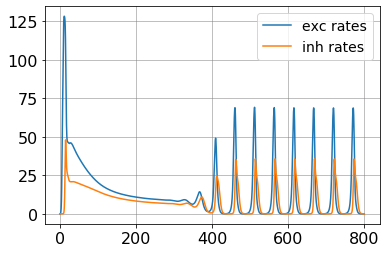

In [4]:
set_params_fast()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

fast_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        fast_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        fast_osc_init[i] = aln.state[state_vars[i]][0,-1]

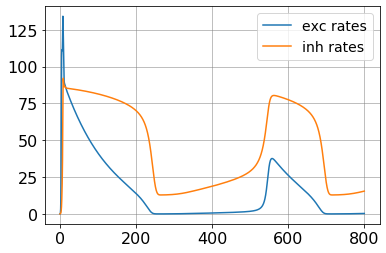

In [5]:
set_params_slow()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

slow_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        slow_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        slow_osc_init[i] = aln.state[state_vars[i]][0,-1]

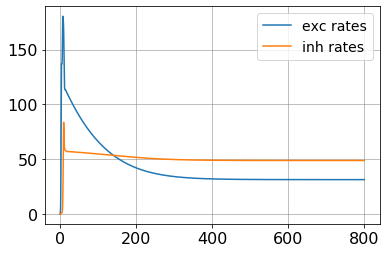

[31.3076 48.768 ]


In [6]:
set_params_up()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

up_rates = np.zeros((2))
up_rates[0] = aln.rates_exc[0,-1]
up_rates[1] = aln.rates_inh[0,-1]

print(up_rates)

up_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        up_init[i] = aln.state[state_vars[i]][0]
    else:
        up_init[i] = aln.state[state_vars[i]][0,-1]

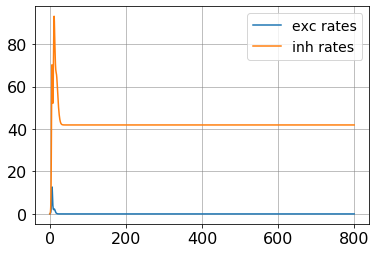

[4.4580e-10 4.1918e+01]


In [7]:
set_params_down()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

down_rates = np.zeros((2))
down_rates[0] = aln.rates_exc[0,-1]
down_rates[1] = aln.rates_inh[0,-1]

print(down_rates)

down_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        down_init[i] = aln.state[state_vars[i]][0]
    else:
        down_init[i] = aln.state[state_vars[i]][0,-1]

In [8]:
def setmaxmincontrol(cntrl_vars):
    max_cntrl = np.zeros(( 4 ))
    min_cntrl = np.zeros(( 4 ))
    if cntrl_vars == [0]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
    elif cntrl_vars == [1]:
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
    elif cntrl_vars == [2]:
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
    elif cntrl_vars == [0,1]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
    elif cntrl_vars == [0,2]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
    elif cntrl_vars == [1,2]:
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
    elif cntrl_vars == [0,1,2]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
            
    return max_cntrl, min_cntrl     

def findclosestindex(osc_rate, stable_rate, startind):
    mindiff = 1000.
    minind = -1
    for t in range(startind, len(osc_rate)):
        diff = np.abs(osc_rate[t] - stable_rate)
        if diff < mindiff:
            mindiff = diff
            minind = t
    return mindiff, minind
        
    
def findclosestindex_2d(osc_rate, stable_rate, startind):
    mindiff = 1000.
    minind = -1
    for t in range(startind, len(osc_rate[0,:])):
        diff = np.abs(osc_rate[0,t] - stable_rate[0]) + np.abs(osc_rate[1,t] - stable_rate[1])
        if diff < mindiff:
            mindiff = diff
            minind = t
    return mindiff, minind

def setpredur(prec_vars):
    if prec_vars == [0]:
        dur_pre = dur_pre_e
    elif prec_vars == [1]:
        dur_pre = dur_pre_i
    else:
        dur_pre = dur_pre_2d
    n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
    
    return dur_pre, n_pre

def settarget(initVars_, dur_, dur_pre_, n_pre_):
    aln.params.duration = dur_

    # set low state rates as target
    target = aln.getZeroTarget()
    target[:,0,n_dt_maxDelay:] = target_rates[0]
    target[:,1,n_dt_maxDelay:] = target_rates[1]

    aln.params.duration = dur_ + dur_pre_
    setinit(initVars_)
    aln.run(control=aln.getZeroControl())
    target[:,0,:n_dt_maxDelay] = aln.rates_exc[0,n_pre_:n_pre_+n_dt_maxDelay]
    target[:,1,:n_dt_maxDelay] = aln.rates_inh[0,n_pre_:n_pre_+n_dt_maxDelay]
    
    aln.params.duration = dur_

    #print(aln.rates_exc[0,n_pre_:n_pre_+n_dt_maxDelay])
    
    return target

    #plt.plot(np.arange(0,dur+0.1,0.1), target[0,0,:])

In [9]:
c_var = [ [0], [1], [2], [0], [1], [2],
         [0,1], [0,1], [0,2], [0,2], [1,2], [1,2],
         [0,1,2], [0,1,2],
         [0], [1], [2], [0,1], [0,2], [1,2], [0,1,2] ]
p_var = [ [0], [1], [0], [1], [0], [1],
         [0], [1], [0], [1], [0], [1],
         [0], [1],
         [0,1], [0,1], [0,1], [0,1], [0,1], [0,1], [0,1] ]

max_it = 50
set_params_fast()
initVars = fast_osc_init

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

sheet = "G_a_"

# 40 timesteps max delay
n_dt_maxDelay = aln.getMaxDelay()

In [10]:
dur = 4000

aln.params.duration = dur

set_params_slow()
setinit(slow_osc_init)
control0 = aln.getZeroControl()

aln.run(control=control0)
mindiff_e, minind_e = findclosestindex(aln.rates_exc[0,:], down_rates[0], n_dt_maxDelay)
print(mindiff_e, minind_e)
dur_pre_e = ( minind_e - n_dt_maxDelay ) / 10.
print(dur_pre_e)

mindiff_i, minind_i = findclosestindex(aln.rates_inh[0,:], down_rates[1], n_dt_maxDelay)
print(mindiff_i, minind_i)
dur_pre_i = ( minind_i - n_dt_maxDelay ) / 10.
print(dur_pre_i)

findclosestindex_2d
mindiff_2d, minind_2d = findclosestindex_2d(np.array( [aln.rates_exc[0,:], aln.rates_inh[0,:]] ),
                                            down_rates, n_dt_maxDelay)
print(mindiff_2d, minind_2d)
dur_pre_2d = ( minind_2d - n_dt_maxDelay ) / 10.
print(dur_pre_2d)

slow_rates = np.array( [aln.rates_exc[0,:], aln.rates_inh[0,:]])

# by mean crossing
def freq_mean_crossing(sig, dt):
    mean_ = np.mean(sig)
    # Find the indices where there's a crossing
    indices = []
    for j in range(len(sig)-1):
        if sig[j] <= mean_ and sig[j+1] >= mean_:
            indices.append(j)
        elif sig[j] >= mean_ and sig[j+1] <= mean_:
            indices.append(j)
    
    if len(indices) < 3:
        print("too short signal, return zero")
        return 0.

    period = 0.
    for j in range(len(indices)-2):
        period += indices[j+2] - indices[j]
    period /= ( len(indices) - 2 )
    period *= dt
    
    return period 

period_slow = freq_mean_crossing(slow_rates[0,:], aln.params.dt)
print("slow period = ", period_slow)

0.014378268271491157 30681
3064.1
0.0009690165794395966 33377
3333.7
1.3730920318880642 12428
1238.8
slow period =  450.9375


## 0

set cost params
------------------------- j =  0
control input:  [0] , precision measure:  [0]
RUN  0 , total integrated cost =  579366.9202143516
RUN  1 , total integrated cost =  155686.71495813722


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  155686.71495813722
Control only changes marginally.
RUN  2 , total integrated cost =  155686.71495813722
Improved over  2  iterations by  73.12813184077942  percent.
Problem in initial value trasfer:  Vmean_exc -56.69677687703519 -56.69674427958635
Problem in initial value trasfer:  Vmean_exc -79.1154758426434 -78.64826268728345
------------------------- j =  1600
control input:  [0] , precision measure:  [0]
RUN  0 , total integrated cost =  538546.6061538191
RUN  1 , total integrated cost =  168941.79675901172


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  168941.79675901172
Control only changes marginally.
RUN  2 , total integrated cost =  168941.79675901172
Improved over  2  iterations by  68.6300508018133  percent.
Problem in initial value trasfer:  Vmean_exc -56.69677687703519 -56.69674427958635
Problem in initial value trasfer:  Vmean_exc -79.24472458132858 -78.77698574970695
------------------------- j =  3200
control input:  [0] , precision measure:  [0]
RUN  0 , total integrated cost =  608979.9050576481
RUN  1 , total integrated cost =  127043.41783432182


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  127043.41783432182
Control only changes marginally.
RUN  2 , total integrated cost =  127043.41783432182
Improved over  2  iterations by  79.13832348502608  percent.
Problem in initial value trasfer:  Vmean_exc -56.69677687703519 -56.69674427958635
Problem in initial value trasfer:  Vmean_exc -79.21310415246069 -78.74549389447706


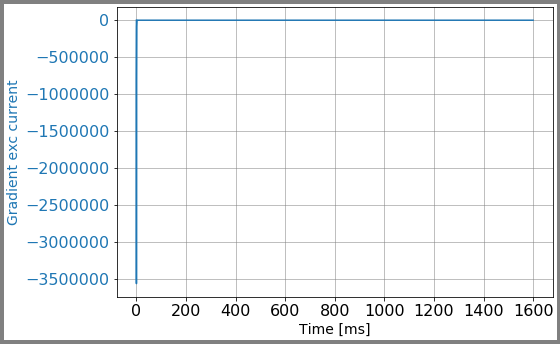

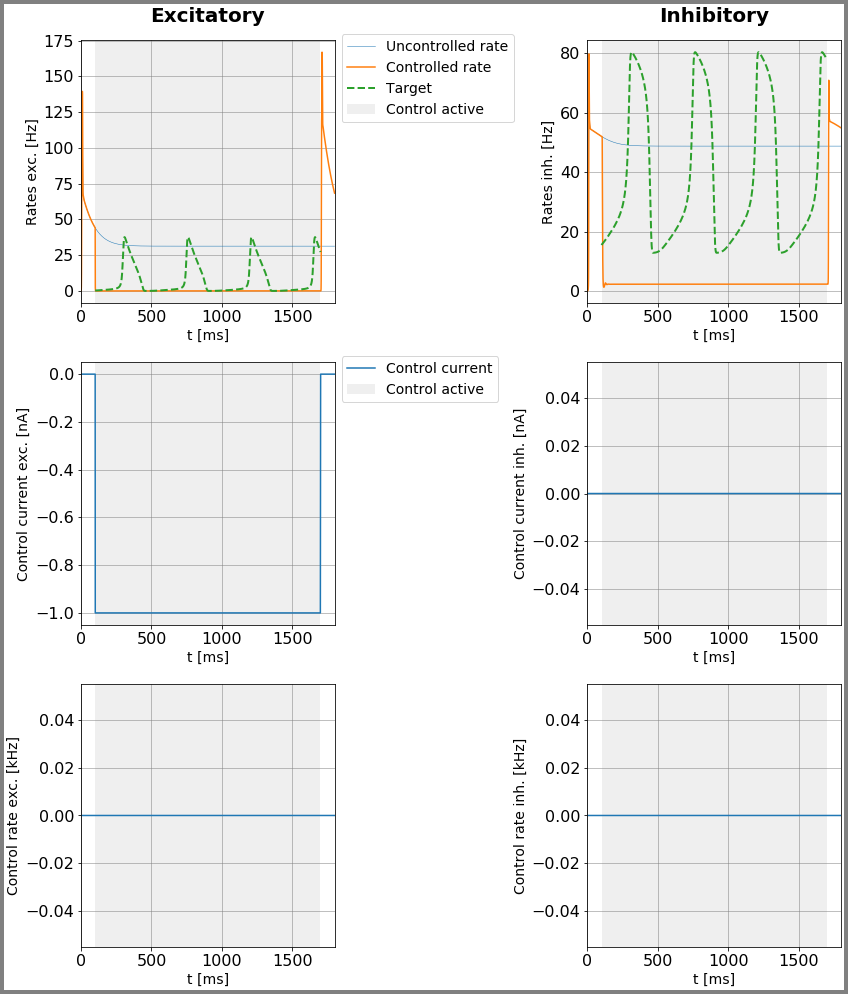

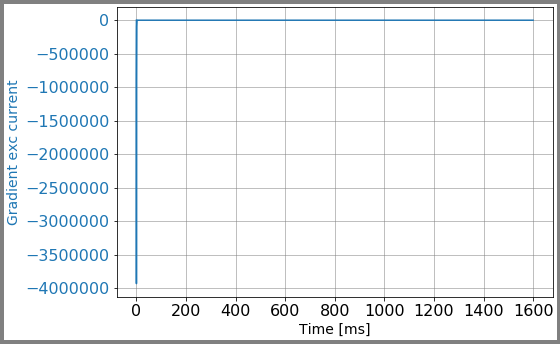

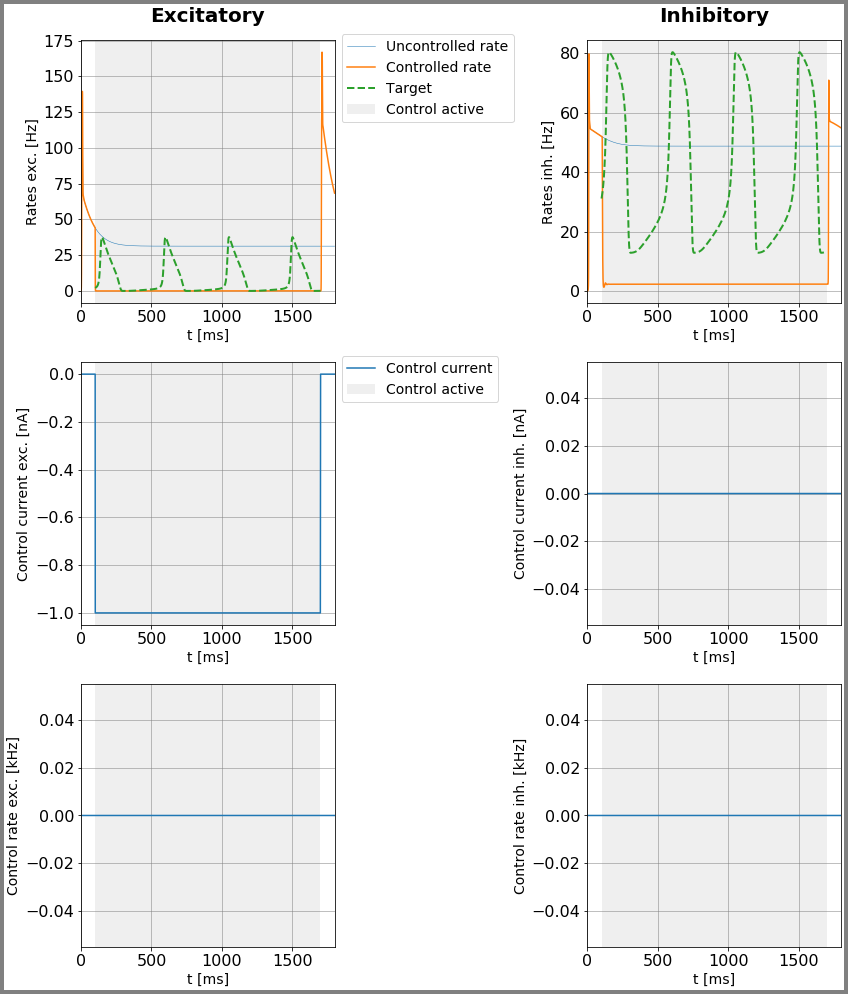

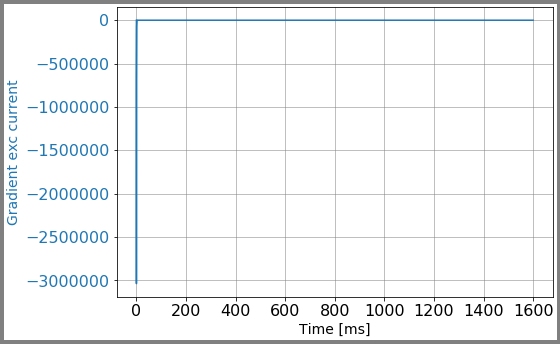

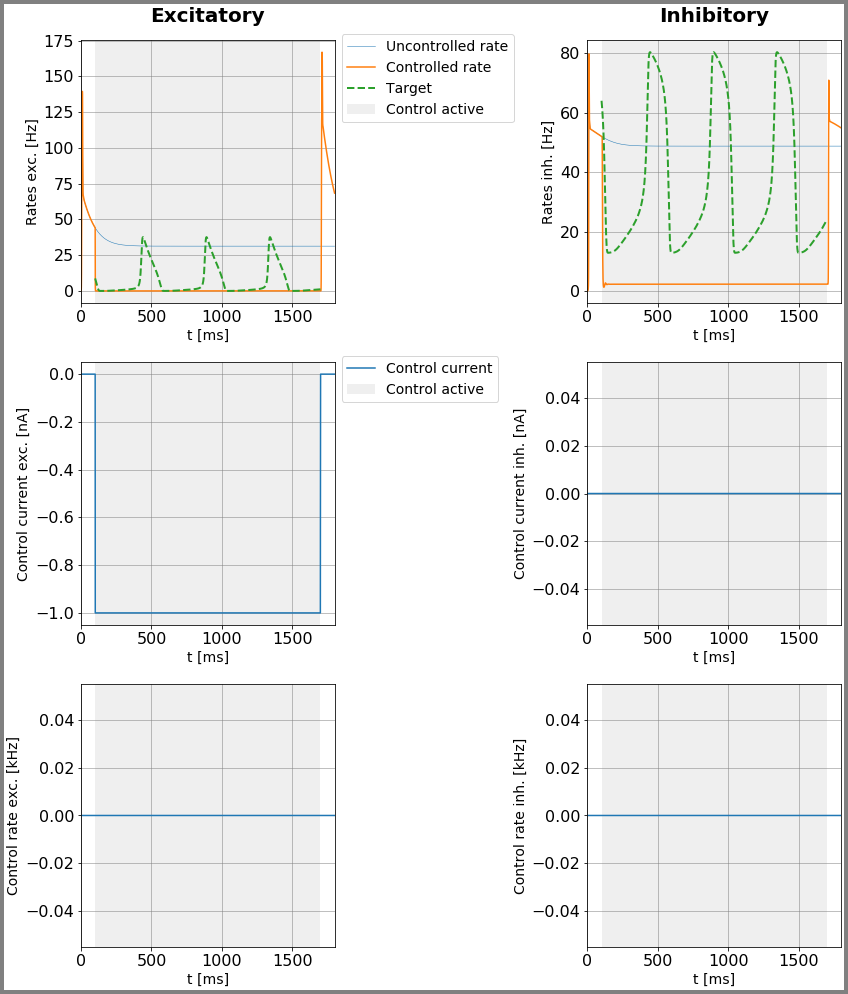

In [11]:
# C.0.a)

dur = 1600
dur_pre = 100
dur_post = 100
n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))
aln.params.duration = dur

case_ind = 0
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

set_params_up()
setinit(initVars)

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)


for j in range(0,int(period_slow/aln.params.dt), 1600):
    print("------------------------- j = ", j)
    aln.params.duration = dur
    target = aln.getZeroTarget()
    target[0,0,:] = slow_rates[0,j:n_dur+j]
    target[0,1,:] = slow_rates[1,j:n_dur+j]

    control0 = aln.getZeroControl()

    #control1 = bestControla[:,:,n_pre-1:-n_post+1]
    #control0[0,0,n_dt_maxDelay:] = -5.

    # "HS", "FR", "PR", "HZ"
    cgv = None

    print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

    bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
        control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

    plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
    plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

In [12]:
"""
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,n_dt_maxDelay:] = -5.
control2 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )
"""

'\n# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity\ncase = sheet + str(case_ind) + "b"\ncost.setParams(1.0, 30.0, 3.0)\n\naln.params.duration = dur\n\nsetinit(initVars)\ncontrol0 = aln.getZeroControl()\ncontrol0[0,0,n_dt_maxDelay:] = -5.\ncontrol2 = bestControla[:,:,n_pre-1:-n_post+1]\n\n# "HS", "FR", "PR", "HZ"\ncgv = None\n\nbestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,\n    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,\n    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,\n    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)\n\nplotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)\nplotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,\n                      path, filename_ = case )\n'

## 2

set cost params
------------------------- j =  0
control input:  [2] , precision measure:  [0]
RUN  0 , total integrated cost =  579366.9202143516
RUN  1 , total integrated cost =  579366.9196253412


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  579366.9196253412
Control only changes marginally.
RUN  2 , total integrated cost =  579366.9196253412
Improved over  2  iterations by  1.0166448305426456e-07  percent.
Problem in initial value trasfer:  Vmean_exc -56.69677687703519 -56.69674427958635
Problem in initial value trasfer:  Vmean_exc -56.6547698412824 -56.655287656309966
------------------------- j =  1600
control input:  [2] , precision measure:  [0]
RUN  0 , total integrated cost =  538546.6061538191
RUN  1 , total integrated cost =  538546.6016485569


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  538546.6016485569
Control only changes marginally.
RUN  2 , total integrated cost =  538546.6016485569
Improved over  2  iterations by  8.365593942016858e-07  percent.
Problem in initial value trasfer:  Vmean_exc -56.69677687703519 -56.69674427958635
Problem in initial value trasfer:  Vmean_exc -56.6547698412824 -56.655287656309966
------------------------- j =  3200
control input:  [2] , precision measure:  [0]
RUN  0 , total integrated cost =  608979.9050576481
RUN  1 , total integrated cost =  608979.9007071502


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  608979.9007071502
Control only changes marginally.
RUN  2 , total integrated cost =  608979.9007071502
Improved over  2  iterations by  7.143910352169769e-07  percent.
Problem in initial value trasfer:  Vmean_exc -56.69677687703519 -56.69674427958635
Problem in initial value trasfer:  Vmean_exc -56.6547698412824 -56.655287656309966


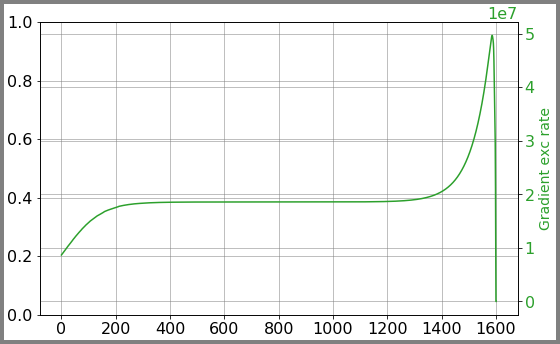

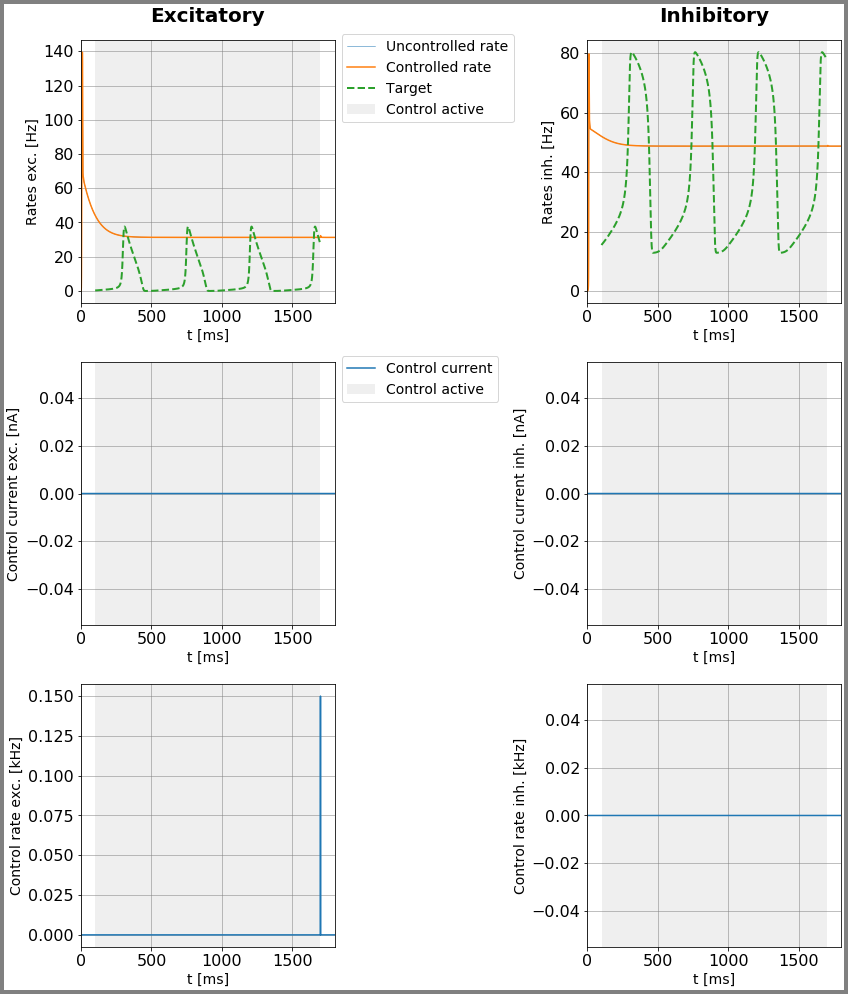

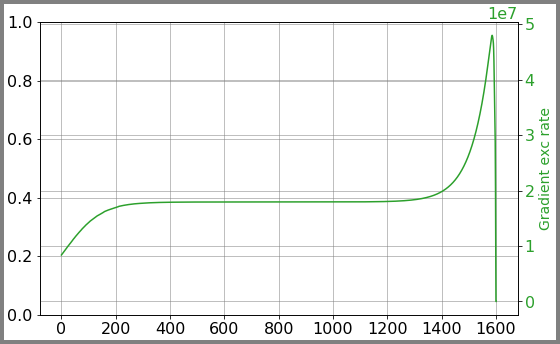

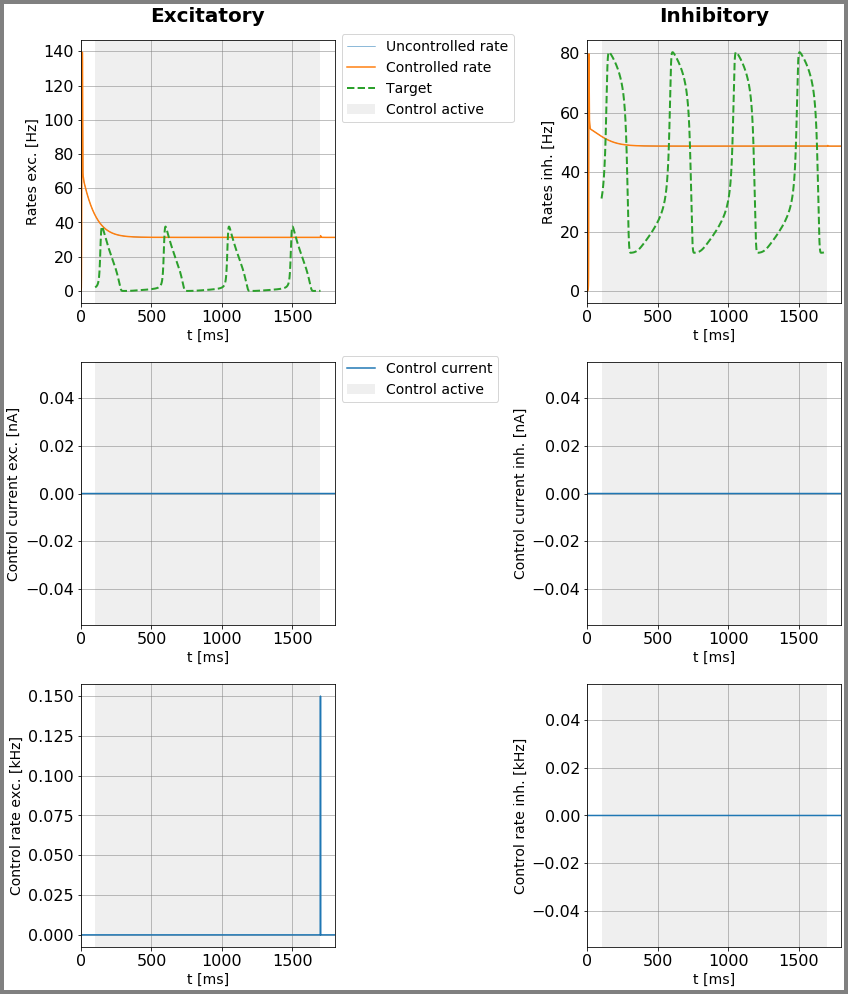

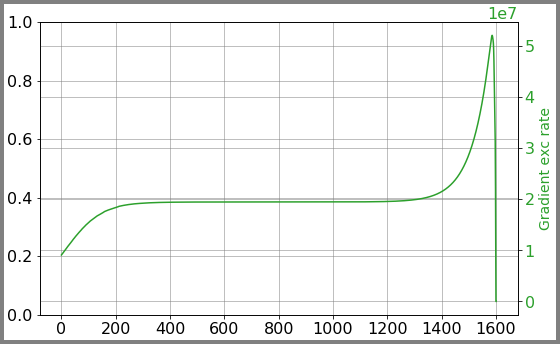

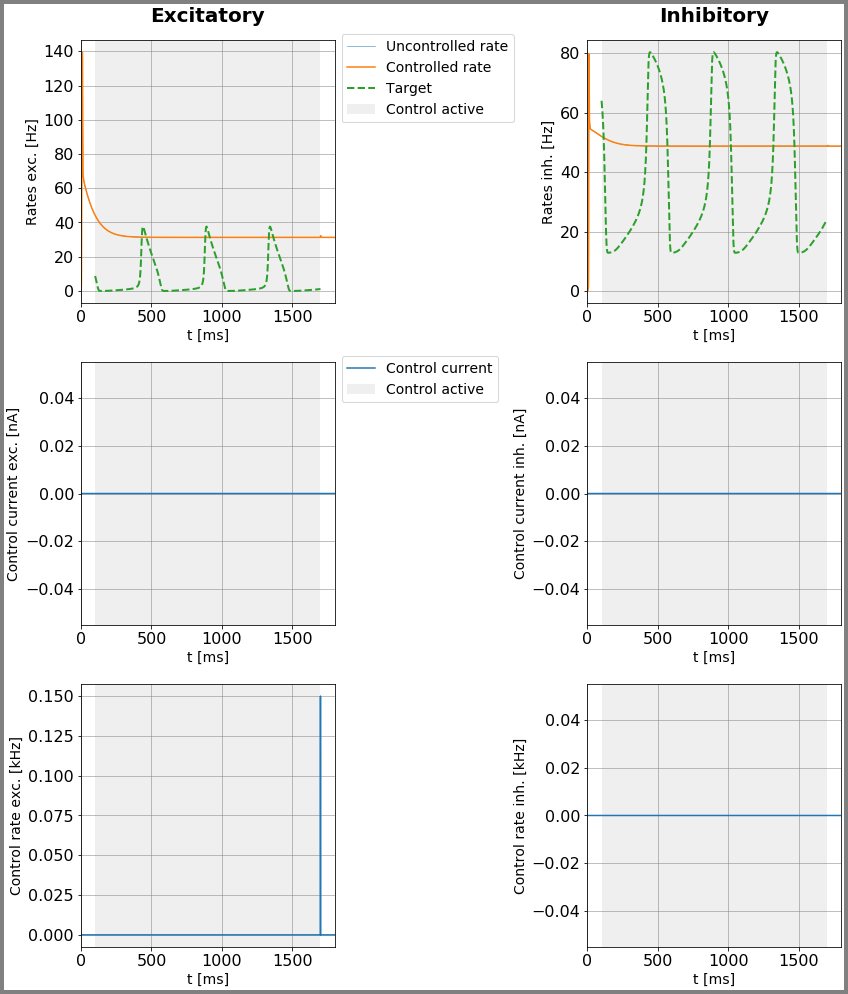

In [15]:
# A.0.a)

case_ind = 2
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

for j in range(0,int(period_slow/aln.params.dt), 1600):
    print("------------------------- j = ", j)
    aln.params.duration = dur
    target = aln.getZeroTarget()
    target[0,0,:] = slow_rates[0,j:n_dur+j]
    target[0,1,:] = slow_rates[1,j:n_dur+j]

    control0 = aln.getZeroControl()

    #control1 = bestControla[:,:,n_pre-1:-n_post+1]
    #control0[0,0,n_dt_maxDelay:] = -5.

    # "HS", "FR", "PR", "HZ"
    cgv = None

    print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

    bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
        control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

    plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
    plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

In [16]:
"""
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
ontrol0 = aln.getZeroControl()
#control0[0,2,:] = 0.
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )
"""

'\n# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity\ncase = sheet + str(case_ind) + "b"\ncost.setParams(1.0, 30.0, 3.0)\n\naln.params.duration = dur\n\nsetinit(initVars)\nontrol0 = aln.getZeroControl()\n#control0[0,2,:] = 0.\ncontrol1 = bestControla[:,:,n_pre-1:-n_post+1]\ncontrol2 = bestControlb[:,:,n_pre-1:-n_post+1]\n\n# "HS", "FR", "PR", "HZ"\ncgv = None\n\nbestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control1, target, c_scheme, u_mat, u_scheme,\n    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,\n    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,\n    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.0)\n\nplotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)\nplotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,\n                      path, filen

## 4

In [ ]:
# A.4.a)

case_ind = 4
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

for j in range(0,int(period_slow/aln.params.dt), 1600):
    print("------------------------- j = ", j)
    aln.params.duration = dur
    target = aln.getZeroTarget()
    target[0,0,:] = slow_rates[0,j:n_dur+j]
    target[0,1,:] = slow_rates[1,j:n_dur+j]

    control0 = aln.getZeroControl()

    #control1 = bestControla[:,:,n_pre-1:-n_post+1]
    #control0[0,0,:] = 5.

    # "HS", "FR", "PR", "HZ"
    cgv = None

    print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

    bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
        control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

    plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
    plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

In [ ]:
"""
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,1,:] = 5.
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )
"""

## 6

In [ ]:
# A.6.a)
case_ind = 6
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

for j in range(0,int(period_slow/aln.params.dt), 1600):
    print("------------------------- j = ", j)
    aln.params.duration = dur
    target = aln.getZeroTarget()
    target[0,0,:] = slow_rates[0,j:n_dur+j]
    target[0,1,:] = slow_rates[1,j:n_dur+j]

    control0 = aln.getZeroControl()

    #control1 = bestControla[:,:,n_pre-1:-n_post+1]
    #control0[0,0,:] = 5.

    # "HS", "FR", "PR", "HZ"
    cgv = None

    print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

    bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
        control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

    plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
    plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

In [ ]:
"""
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,n_dt_maxDelay:] = -0.5
control0[0,1,:] = 3.
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

"""

## 8

In [ ]:
# A.8.a)
case_ind = 8
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

for j in range(0,int(period_slow/aln.params.dt), 1600):
    print("------------------------- j = ", j)
    aln.params.duration = dur
    target = aln.getZeroTarget()
    target[0,0,:] = slow_rates[0,j:n_dur+j]
    target[0,1,:] = slow_rates[1,j:n_dur+j]

    control0 = aln.getZeroControl()

    #control1 = bestControla[:,:,n_pre-1:-n_post+1]
    #control0[0,0,:] = 5.

    # "HS", "FR", "PR", "HZ"
    cgv = None

    print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

    bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
        control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

    plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
    plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

In [ ]:
"""
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,:] = -5.
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True,
            crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )
                      """

## 10

In [ ]:
# A.10.a)
case_ind = 10
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

for j in range(0,int(period_slow/aln.params.dt), 1600):
    print("------------------------- j = ", j)
    aln.params.duration = dur
    target = aln.getZeroTarget()
    target[0,0,:] = slow_rates[0,j:n_dur+j]
    target[0,1,:] = slow_rates[1,j:n_dur+j]

    control0 = aln.getZeroControl()

    #control1 = bestControla[:,:,n_pre-1:-n_post+1]
    #control0[0,0,:] = 5.

    # "HS", "FR", "PR", "HZ"
    cgv = None

    print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

    bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
        control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

    plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
    plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

In [ ]:
"""
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,1,:] = 0.75
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True,
            crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )
"""

## 12

In [ ]:
# A.12.a)
case_ind = 12
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

for j in range(0,int(period_slow/aln.params.dt), 1600):
    print("------------------------- j = ", j)
    aln.params.duration = dur
    target = aln.getZeroTarget()
    target[0,0,:] = slow_rates[0,j:n_dur+j]
    target[0,1,:] = slow_rates[1,j:n_dur+j]

    control0 = aln.getZeroControl()

    #control1 = bestControla[:,:,n_pre-1:-n_post+1]
    #control0[0,0,:] = 5.

    # "HS", "FR", "PR", "HZ"
    cgv = None

    print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

    bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
        control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

    plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
    plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

In [ ]:
"""
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,n_dt_maxDelay:] = -0.8
#control0[0,1,:] = 5.
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )
                      """